# Plots 

In [ ]:
# Line plot
plt.figure(figsize=(12, 12))
plt.plot(pue_oc_df['ts'], pue_oc_df['outdoor_air_temp'], label='Temperature', color='steelblue')
plt.xlabel('Timestamp')
plt.ylabel('Temperature')
plt.title('Temperature over Time')
plt.legend()
plt.tight_layout()
plt.show()

# Histogram
plt.hist(pue_oc_df['outdoor_air_temp'], bins=50, edgecolor='black')

# Scatter
plt.scatter(pue_oc_df['outdoor_air_temp'], pue_oc_df['outdoor_air_humidity'], alpha=0.3)

# Subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0, 0].plot(pue_oc_df['outdoor_air_temp'])

KeyboardInterrupt: 

In [ ]:
# Drop the column
pue_c_df.drop(columns='tags', inplace=True)

In [ ]:
pue_c_df.head()

In [ ]:
pue_c_df.columns

In [37]:
plt.figure(figsize=(12, 8))
sns.heatmap(pue_c_df.corr(), annot=True, fmt='.2f', cmap = 'coolwarm')
plt.tight_layout()
plt.show()

ValueError: could not convert string to float: 'Sun Jun 12 2016 00:00:18 GMT-0600 (Mountain Daylight Time)'

<Figure size 1200x800 with 0 Axes>

### Heatmap Findings:

pue_c_df

**Strong**
- hvac_kw & it_power_kw
- pue & ere (energy reuse effectiveness)
- pump_kw & it_power_kw

**Moderate**
- hvac_kw & pump_kw

pue_oc_df

- No features are highly correlated.

In [ ]:
# Core relationship - IT load driving cooling overhead
sns.scatterplot(x='it_power_kw', y='hvac_kw', data=pue_c_df, alpha = 0.1)

<Axes: xlabel='pue', ylabel='ere'>

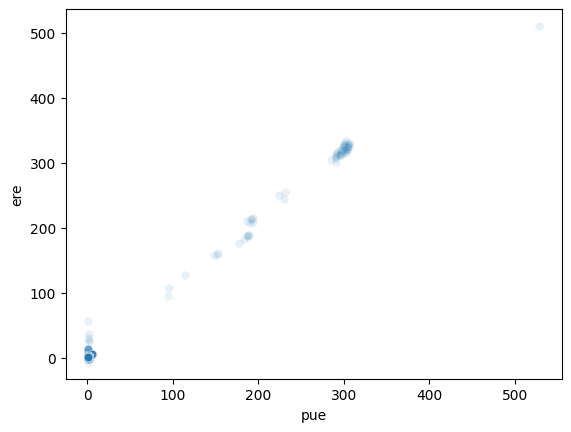

In [34]:
# HVAC response to compute load
sns.scatterplot(x='pue', y='ere', data=pue_c_df, alpha = 0.1)

<Axes: xlabel='pue', ylabel='energy_reuse'>

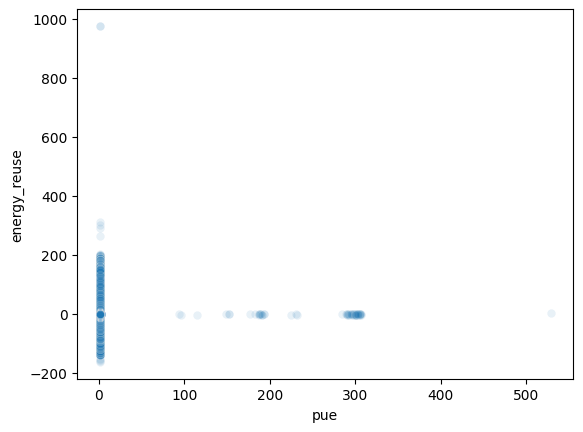

In [36]:
sns.scatterplot(x='pue', y='energy_reuse', data=pue_c_df, alpha=0.1)

In [ ]:
# Rollin PUE over time - reveals seasonal patterns
pue_c_df_sorted = pue_c_df.sort_values('ts')
plt.plot(pue_c_df_sorted['ts'],
         pue_c_df_sorted['pue'].rolling(window=1440).mean())
plt.title('PUE over Time')

In [ ]:
pue_c_df.columns

In [ ]:
# Take a representative sample for plotting only
plot_df = pue_c_df.sample(n=10000, random_state=42)

# Now run all your plots on plot_df instead
sns.histplot(plot_df['pue'], kde=True)
sns.pairplot(plot_df[['pue', 'cooling_kw', 'it_power_kw', 'ere']])
sns.regplot(x='ere', y='pue', data=plot_df)
sns.boxplot(x=plot_df['pue'])

In [ ]:
print(pue_c_df['ere'].describe())
print(f'ERE below 0: {(pue_c_df["ere"] < 0).sum()}')
print(f'ERE above 2: {(pue_c_df["ere"] > 2).sum()}')

In [ ]:
print(pue_c_df['cooling_kw'].describe())
print(f'cooling_kw above 100: {(pue_c_df["cooling_kw"] > 100).sum()}')

In [ ]:
# 1. Drop ere — mathematically derived from pue
pue_c_df.drop(columns=['ere'], inplace=True)

# 2. Investigate energy_reuse
print(pue_c_df['energy_reuse'].describe())
print(f'Non-zero values: {(pue_c_df["energy_reuse"] != 0).sum()}')

# 3. Cap cooling_kw outliers
cooling_99 = pue_c_df['cooling_kw'].quantile(0.99)
print(f'99th percentile cooling_kw: {cooling_99}')
pue_c_df = pue_c_df[pue_c_df['cooling_kw'] <= cooling_99]

# 4. Check skew on all features
for col in ['cooling_kw', 'hvac_kw', 'it_power_kw', 'plug_and_light_kw', 'pump_kw']:
    print(f'{col}: skew={pue_c_df[col].skew():.2f}')

In [ ]:
import plotly.express as px

# Sample for performance — same logic as seaborn
plot_df = pue_c_df.sample(n=10000, random_state=42)

# PUE over time — use hourly resampled data, not raw or sampled
pue_hourly = pue_c_df.set_index('ts').resample('1H')['pue'].mean().reset_index()
fig = px.line(pue_hourly, x='ts', y='pue', title='PUE Over Time (Hourly Mean)')
fig.show()

# Scatter — sampled
fig = px.scatter(plot_df, x='outside_air_temp', y='pue', 
                 color='day', title='PUE vs Outside Air Temp')
fig.show()

# Histogram — sampled
fig = px.histogram(plot_df, x='pue', nbins=50, title='PUE Distribution')
fig.show()

# Correlation heatmap — use full data but corr() reduces it to a small matrix anyway
numeric_cols = ['cooling_kw', 'hvac_kw', 'it_power_kw', 
                'plug_and_light_kw', 'pump_kw', 'pue']
fig = px.imshow(pue_c_df[numeric_cols].corr(), 
                text_auto='.2f', 
                color_continuous_scale='RdBu_r',
                title='Feature Correlation Matrix')
fig.show()